<a href="https://colab.research.google.com/github/BabimBeam/BSC_DPDM2025/blob/main/Ch5_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#DATA

In [1]:
from sklearn.datasets import load_digits

# Load the MNIST dataset (digits dataset is a subset of MNIST)
digits = load_digits()
X = digits.data
y = digits.target

print(f"Shape of data (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")
print(f"Number of classes: {len(digits.target_names)}")
print(f"First 5 target labels: {digits.target[:5]}")

Shape of data (X): (1797, 64)
Shape of target (y): (1797,)
Number of classes: 10
First 5 target labels: [0 1 2 3 4]


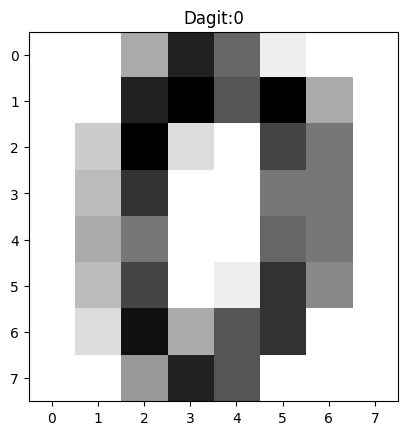

In [2]:
import matplotlib.pyplot as plt

# Get the first image and its target label
first_image = X[0]
first_label = y[0]

# Reshape the 64-feature vector to an 8x8 image
image_reshaped = first_image.reshape(8, 8)

# Display the image
plt.imshow(image_reshaped, cmap=plt.cm.gray_r, interpolation='nearest')
plt.title(f"Dagit:{first_label}")
plt.show()

In [3]:
digits.data

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]])

In [4]:
import pandas as pd

df = pd.DataFrame(digits.data)
df['target'] = digits.target
df.shape

(1797, 65)

In [5]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [6]:
X.shape

(1797, 64)

In [7]:
X_train = X[:1700]
y_train = y[:1700]
X_test = X[1700:]
y_test = y[1700:]

# Model Construction


*   import
*   define (hyper-parameters)
*   train (fitting)
*   evaluate (train vs test)





## import

In [8]:
from sklearn.tree import DecisionTreeClassifier

## define

In [9]:
tree0 = DecisionTreeClassifier(random_state=6)

## Training

In [10]:
tree0.fit(X_train, y_train)

DecisionTreeClassifier(random_state=6)

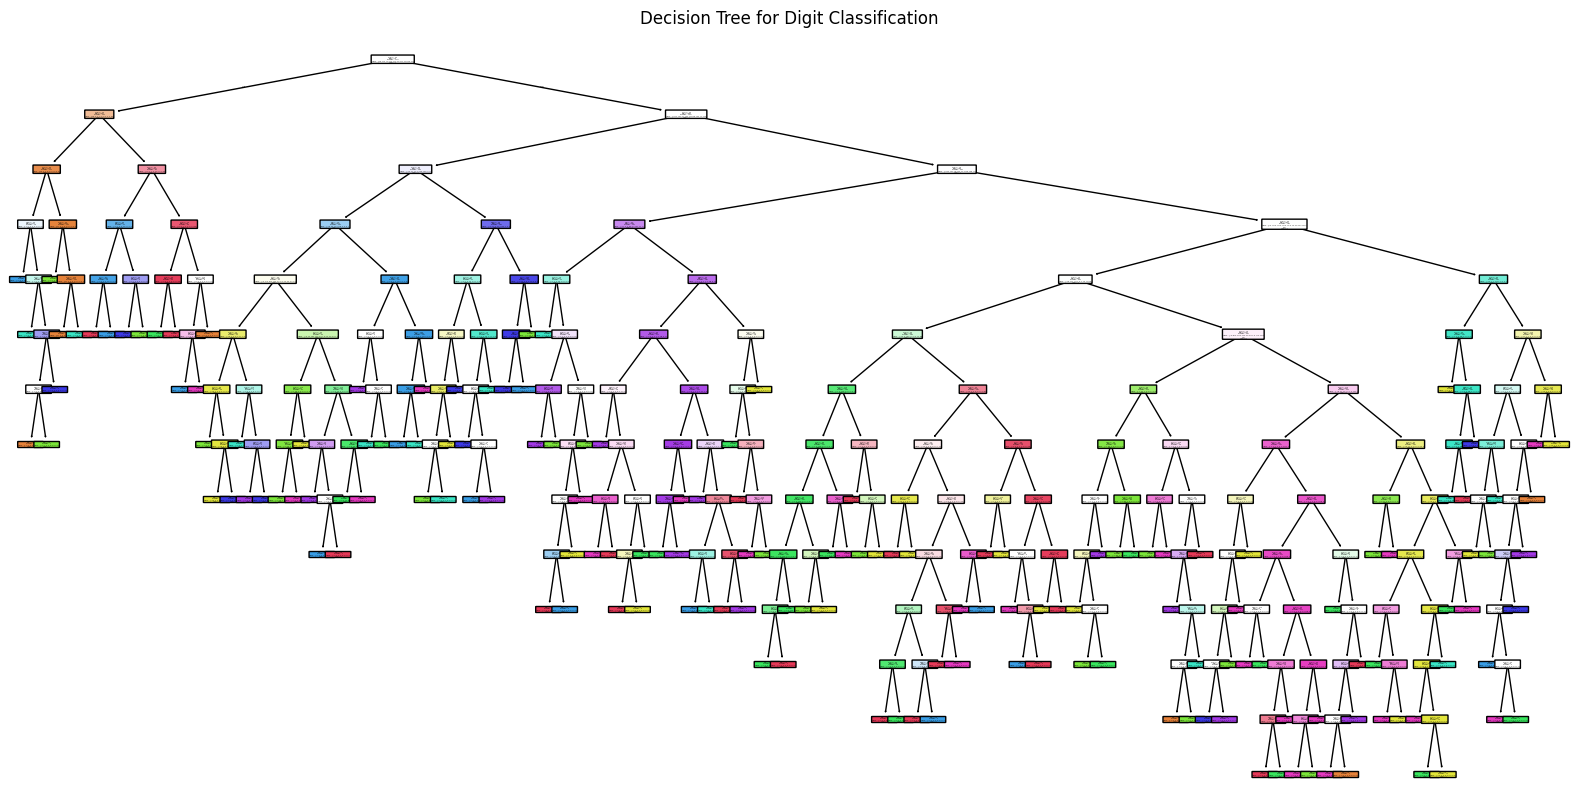

In [11]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10)) # Adjust figure size for better visibility
plot_tree(tree0, filled=True , rounded=True , class_names=digits.target_names.astype(str))
plt.title("Decision Tree for Digit Classification")
plt.show()

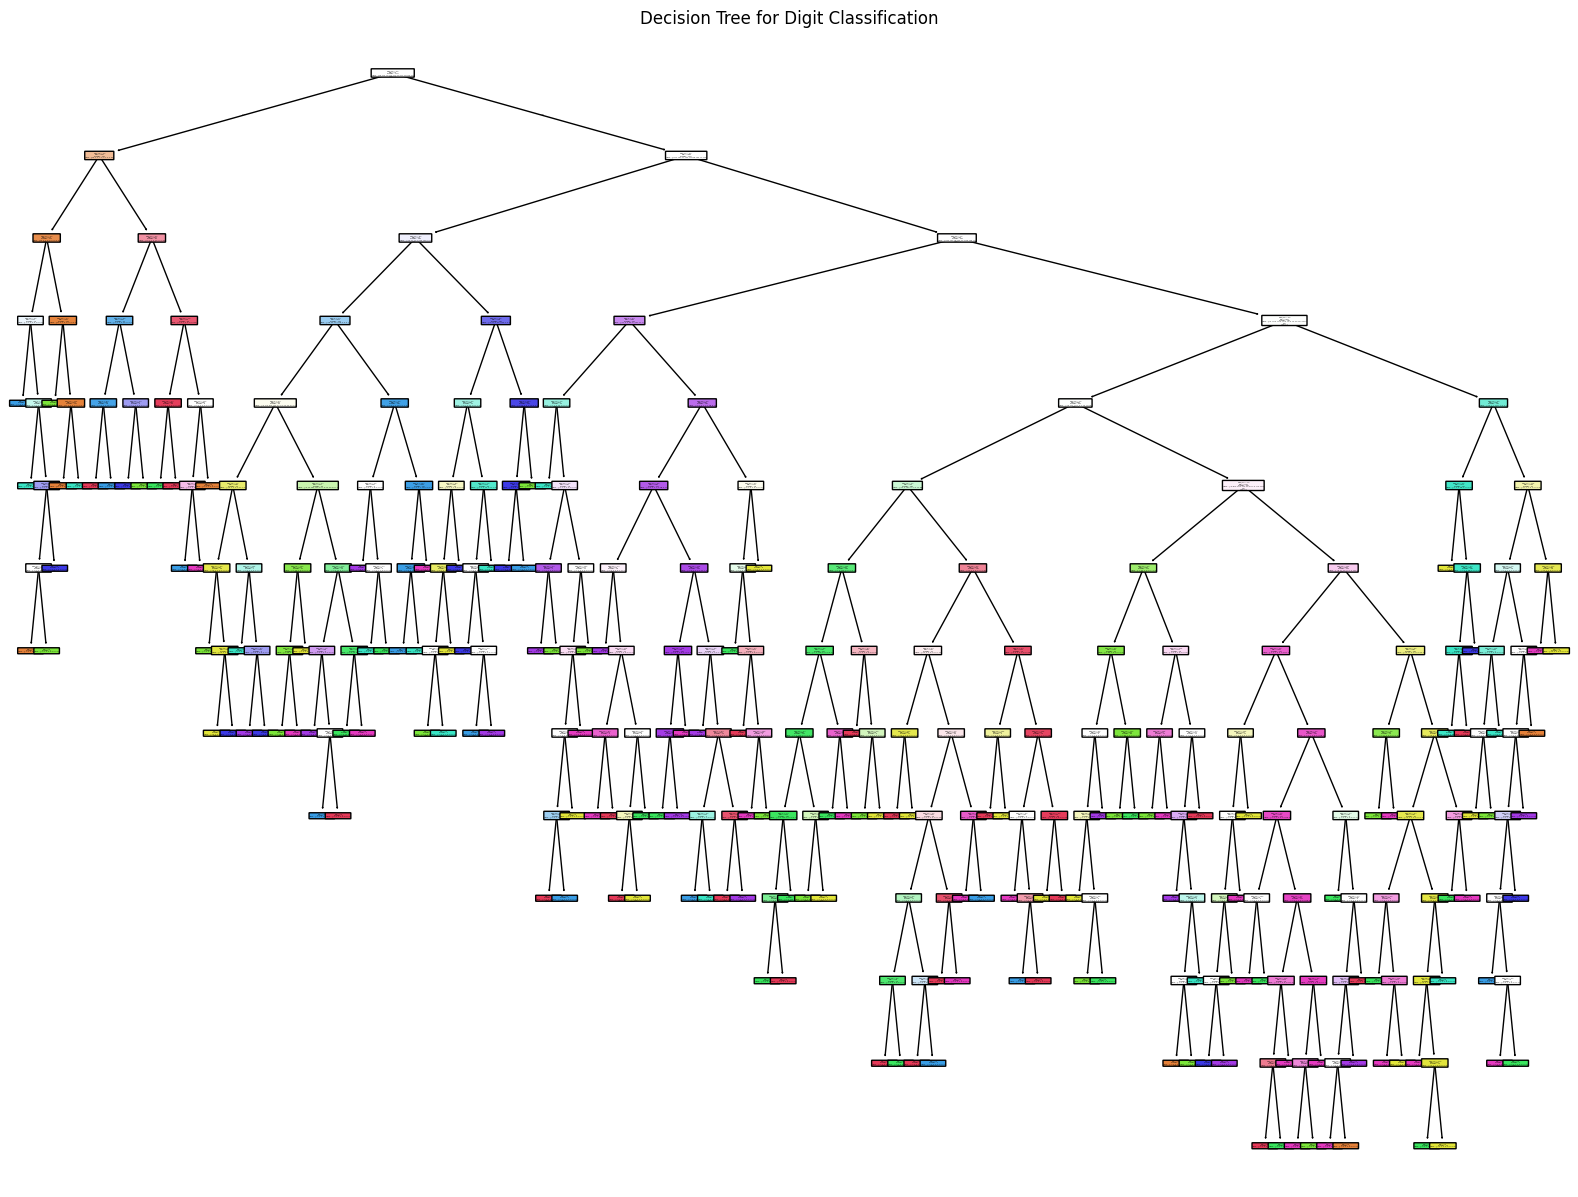

In [12]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Get feature names and class names for better visualization
feature_names = [f'pixel_{i}' for i in range(X.shape[1])]
class_names = [str(i) for i in digits.target_names]

plt.figure(figsize=(20,15)) # Adjust figure size for better visibility
plot_tree(tree0, feature_names=feature_names, class_names=class_names, filled=True, rounded=True)
plt.title("Decision Tree for Digit Classification")
plt.show()

## Evaluate

In [13]:
train_accuracy = tree0.score(X_train, y_train)
test_accuracy = tree0.score(X_test, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Training Accuracy: 1.0000
Test Accuracy: 0.7938


In [14]:
y_predict = tree0.predict(X_test)
y_predict

array([8, 6, 5, 0, 9, 8, 9, 8, 4, 1, 7, 7, 9, 5, 1, 0, 0, 6, 2, 7, 8, 2,
       0, 3, 8, 6, 8, 8, 7, 4, 3, 4, 6, 6, 6, 4, 9, 1, 9, 0, 9, 6, 7, 8,
       2, 0, 0, 6, 7, 6, 8, 2, 1, 7, 4, 6, 3, 1, 2, 9, 1, 7, 6, 8, 4, 8,
       1, 4, 0, 5, 5, 6, 9, 6, 1, 7, 5, 4, 4, 7, 2, 5, 2, 2, 5, 7, 9, 4,
       4, 3, 3, 4, 9, 0, 8, 9, 8])

In [15]:
y_test

array([5, 6, 5, 0, 9, 8, 9, 8, 4, 1, 7, 7, 3, 5, 1, 0, 0, 2, 2, 7, 8, 2,
       0, 1, 2, 6, 3, 3, 7, 3, 3, 4, 6, 6, 6, 4, 9, 1, 5, 0, 9, 5, 2, 8,
       2, 0, 0, 1, 7, 6, 3, 2, 1, 7, 4, 6, 3, 1, 3, 9, 1, 7, 6, 8, 4, 3,
       1, 4, 0, 5, 3, 6, 9, 6, 1, 7, 5, 4, 4, 7, 2, 8, 2, 2, 5, 7, 9, 5,
       4, 8, 8, 4, 9, 0, 8, 9, 8])

In [16]:
from sklearn.metrics import accuracy_score

In [17]:
accuracy_score(y_test, y_predict)

0.7938144329896907

## pre-pruning (hyper-parameter tuning)

In [18]:
from sklearn.tree import DecisionTreeClassifier
tree1 = DecisionTreeClassifier(random_state=6 , max_depth=3)
tree1.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=6)

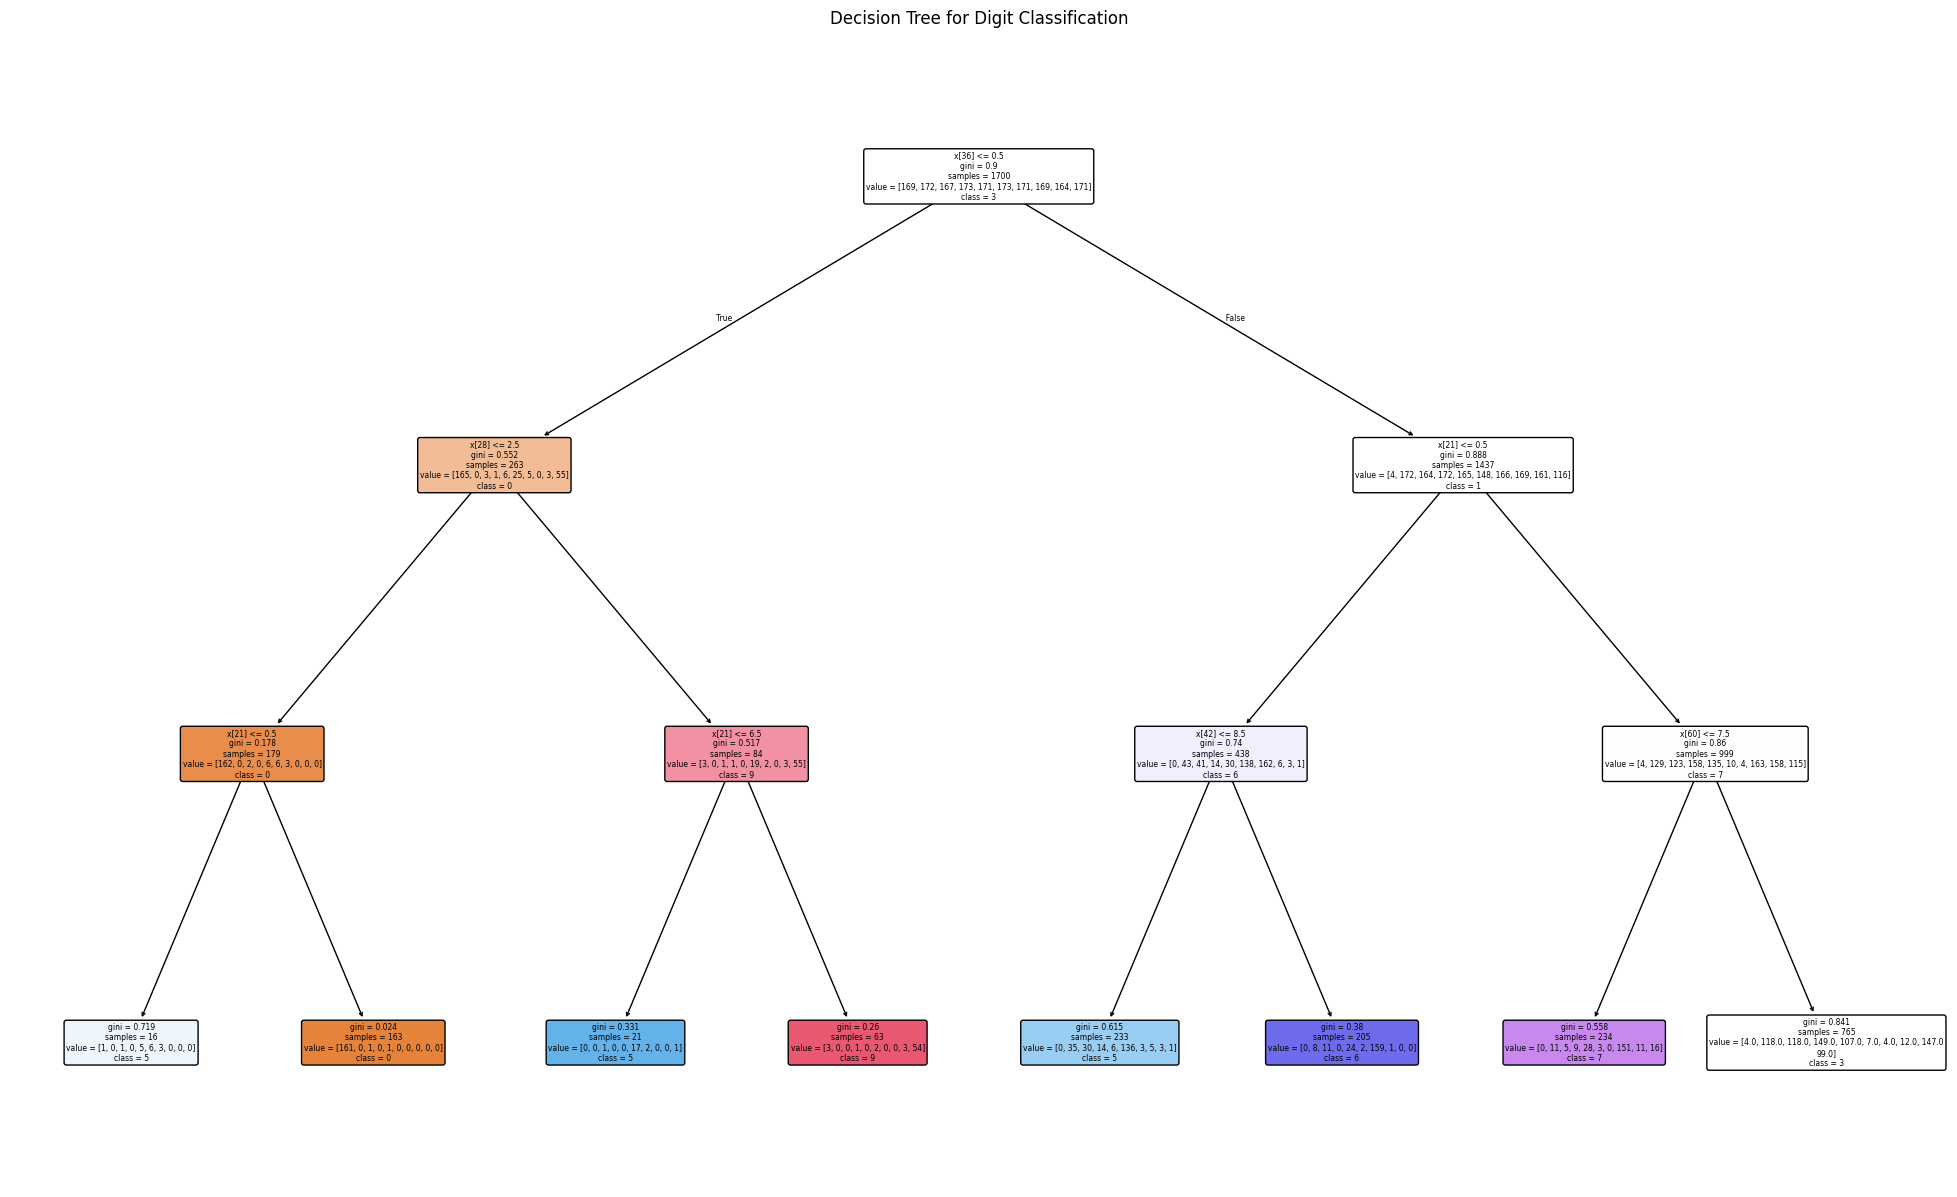

In [19]:
plt.figure(figsize=(25,15)) # Adjust figure size for better visibility
plot_tree(tree1 , filled=True , rounded=True , class_names=digits.target_names.astype(str))
plt.title("Decision Tree for Digit Classification")
plt.show()

## Evaluate

In [20]:
y_predict1 = tree1.predict(X_test)
accuracy_score(y_test, y_predict1)

0.4639175257731959

##Tree2

In [21]:
from sklearn.tree import DecisionTreeClassifier
tree2 = DecisionTreeClassifier(random_state=6 , max_depth=7)
tree2.fit(X_train, y_train)
y_predict2 = tree2.predict(X_test)
accuracy_score(y_test, y_predict2)

0.7938144329896907

# Quiz 11
tune hyper-parameters so that the accuracy is better than default (at random_state = 6 )

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree_best = DecisionTreeClassifier(random_state=5, max_depth=10)
tree_best.fit(X_train, y_train)

# Make predictions on the test set
y_predict_best = tree_best.predict(X_test)

# Calculate and print the accuracy
accuracy_best = accuracy_score(y_test, y_predict_best)
print(f"Accuracy with best max_depth (10): {accuracy_best:.4f}")

Accuracy with best max_depth (10): 0.8763


# Model Selection and


create a workflow composed of
1. train and test splitting which train and test have the same class distribution
2. in training data, we split it into 10-fold
3. perform cross validation and grid search (10 KNN and 10 decision trees)
4. use Accuracy as a metric
5. Evaluate the best model with test set and report

# Task
Perform a stratified train-test split on the digits dataset, then use 10-fold cross-validation and grid search to tune and select the best K-Nearest Neighbors (KNN) or Decision Tree model based on accuracy, and finally evaluate the best model on the independent test set.

## Train-Test Split

### Subtask:
Perform a stratified train-test split on the dataset to ensure both sets have the same class distribution.


**Reasoning**:
To perform a stratified train-test split, I need to import the `train_test_split` function from `sklearn.model_selection` and then apply it to the data with the specified parameters.



In [23]:
from sklearn.model_selection import train_test_split

X_train_strat, X_test_strat, y_train_strat, y_test_strat = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train_strat shape: {X_train_strat.shape}")
print(f"y_train_strat shape: {y_train_strat.shape}")
print(f"X_test_strat shape: {X_test_strat.shape}")
print(f"y_test_strat shape: {y_test_strat.shape}")

X_train_strat shape: (1437, 64)
y_train_strat shape: (1437,)
X_test_strat shape: (360, 64)
y_test_strat shape: (360,)


## Define Models and Hyperparameters

### Subtask:
Define the K-Nearest Neighbors (KNN) and Decision Tree classifiers, along with their respective hyperparameter grids for tuning.


**Reasoning**:
To define the models and their hyperparameter grids, I need to import the `KNeighborsClassifier` and `DecisionTreeClassifier` classes from `sklearn` and then create the specified hyperparameter dictionaries.



In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Define hyperparameter grid for KNN
param_grid_knn = {
    'n_neighbors': list(range(1, 11))  # Example: check n_neighbors from 1 to 10
}

# Define hyperparameter grid for Decision Tree
param_grid_dt = {
    'max_depth': list(range(1, 11)),  # Example: check max_depth from 1 to 10
    'criterion': ['gini', 'entropy']  # Example: check both 'gini' and 'entropy' criteria
}

print("KNN and Decision Tree classifiers and their hyperparameter grids defined.")

KNN and Decision Tree classifiers and their hyperparameter grids defined.


**Reasoning**:
Now that the models and their hyperparameter grids are defined, the next step is to set up and perform a grid search with 10-fold cross-validation for both KNN and Decision Tree models. This will allow us to find the best hyperparameters for each model.



In [25]:
from sklearn.model_selection import GridSearchCV

# Setup GridSearchCV for KNN
grid_search_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=10, scoring='accuracy', n_jobs=-1)
print("Starting GridSearchCV for KNN...")
grid_search_knn.fit(X_train_strat, y_train_strat)
print("GridSearchCV for KNN completed.")

# Setup GridSearchCV for Decision Tree
grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=10, scoring='accuracy', n_jobs=-1)
print("Starting GridSearchCV for Decision Tree...")
grid_search_dt.fit(X_train_strat, y_train_strat)
print("GridSearchCV for Decision Tree completed.")

print(f"Best parameters for KNN: {grid_search_knn.best_params_}")
print(f"Best accuracy for KNN: {grid_search_knn.best_score_:.4f}")

print(f"Best parameters for Decision Tree: {grid_search_dt.best_params_}")
print(f"Best accuracy for Decision Tree: {grid_search_dt.best_score_:.4f}")

Starting GridSearchCV for KNN...
GridSearchCV for KNN completed.
Starting GridSearchCV for Decision Tree...
GridSearchCV for Decision Tree completed.
Best parameters for KNN: {'n_neighbors': 3}
Best accuracy for KNN: 0.9896
Best parameters for Decision Tree: {'criterion': 'gini', 'max_depth': 9}
Best accuracy for Decision Tree: 0.8643


**Reasoning**:
After performing grid search and identifying the best parameters for both KNN and Decision Tree, the next logical step is to compare their best cross-validation scores to determine the overall best model. Then, I will evaluate this selected best model on the independent stratified test set (`X_test_strat`, `y_test_strat`) to get its final performance metric.



In [26]:
print("\n--- Model Selection and Final Evaluation ---")

# Compare the best scores from both models
if grid_search_knn.best_score_ > grid_search_dt.best_score_:
    best_model = grid_search_knn.best_estimator_
    model_name = "K-Nearest Neighbors"
    best_cv_score = grid_search_knn.best_score_
else:
    best_model = grid_search_dt.best_estimator_
    model_name = "Decision Tree"
    best_cv_score = grid_search_dt.best_score_

print(f"The best model based on cross-validation is: {model_name}")
print(f"Best cross-validation accuracy: {best_cv_score:.4f}")

# Evaluate the best model on the independent test set
test_accuracy_final = best_model.score(X_test_strat, y_test_strat)

print(f"Final test accuracy of the {model_name} model: {test_accuracy_final:.4f}")


--- Model Selection and Final Evaluation ---
The best model based on cross-validation is: K-Nearest Neighbors
Best cross-validation accuracy: 0.9896
Final test accuracy of the K-Nearest Neighbors model: 0.9861


## Summary:

### Q&A
The best model selected based on 10-fold cross-validation accuracy is the K-Nearest Neighbors (KNN) model with `n_neighbors=3`. This model achieved a final test accuracy of 0.9861 on the independent test set.

### Data Analysis Key Findings
*   A stratified train-test split was performed on the dataset, resulting in a training set of 1437 samples and a test set of 360 samples.
*   Hyperparameter grids were defined for both K-Nearest Neighbors (KNN) and Decision Tree classifiers. For KNN, `n_neighbors` was tuned from 1 to 10. For Decision Tree, `max_depth` was tuned from 1 to 10, and `criterion` included 'gini' and 'entropy'.
*   Using 10-fold cross-validation and grid search:
    *   The best KNN model found had `n_neighbors=3`, achieving a cross-validation accuracy of 0.9896.
    *   The best Decision Tree model found had `criterion='gini'` and `max_depth=9`, achieving a cross-validation accuracy of 0.8643.
*   Comparing the cross-validation scores, the KNN model was identified as superior.
*   The selected best KNN model (with `n_neighbors=3`) was evaluated on the independent test set and achieved a final test accuracy of 0.9861.

### Insights or Next Steps
*   The KNN model demonstrates excellent generalization performance on unseen data, as indicated by its high accuracy on the independent test set, which is very close to its cross-validation accuracy.
*   Further analysis could involve exploring other classification algorithms (e.g., Support Vector Machines, Random Forests) or performing error analysis on misclassified digits to identify common patterns of confusion.
